<center>
<img src="https://supportvectors.ai/logo-poster-transparent.png" width=400px style="opacity:0.8">
</center>

# Memory-Derived Indexing Graph

After conflict resolution, memory is projected into a heterogeneous graph with:

- type and schema nodes
- entity nodes and fact edges
- passage evidence links
- optional similarity bridges between entities

In [1]:
%run supportvectors-common.ipynb



<div style="color:#aaa;font-size:8pt">
<hr/>
&copy; SupportVectors. All rights reserved. <blockquote>This notebook is the intellectual property of SupportVectors, and part of its training material. 
Only the participants in SupportVectors workshops are allowed to study the notebooks for educational purposes currently, but is prohibited from copying or using it for any other purposes without written permission.

<b> These notebooks are chapters and sections from Asif Qamar's textbook that he is writing on Data Science. So we request you to not circulate the material to others.</b>
 </blockquote>
 <hr/>
</div>



In [2]:

from memg_concepts.config import DEFAULT_PDF
from memg_concepts.pipeline import build_index

index = build_index(DEFAULT_PDF, max_chunks=10)
print('Memory:', index.memory.summary())
print('Graph:', index.graph.summary())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Memory: {'passages': 10, 'schemas': 80, 'stable_schemas': 4, 'facts': 112, 'active_facts': 12}
Graph: {'nodes': 31, 'edges': 68, 'type': 3, 'entity': 14, 'passage': 10, 'schema': 4}


In [3]:
import networkx as nx

G = nx.Graph()
for node_id, node in index.graph.nodes.items():
    G.add_node(node_id, kind=node.kind.value, label=node.label)
for edge in index.graph.edges:
    G.add_edge(edge.source, edge.target, relation=edge.relation, weight=edge.weight)

print('Connected components:', nx.number_connected_components(G))
print('Sample edges:', [(e.source, e.relation, e.target) for e in index.graph.edges[:6]])

Connected components: 6
Sample edges: [('schema:model:is:concept', 'head_type', 'type:model'), ('schema:model:is:concept', 'tail_type', 'type:concept'), ('schema:model:uses:concept', 'head_type', 'type:model'), ('schema:model:uses:concept', 'tail_type', 'type:concept'), ('schema:person:designed:concept', 'head_type', 'type:person'), ('schema:person:designed:concept', 'tail_type', 'type:concept')]


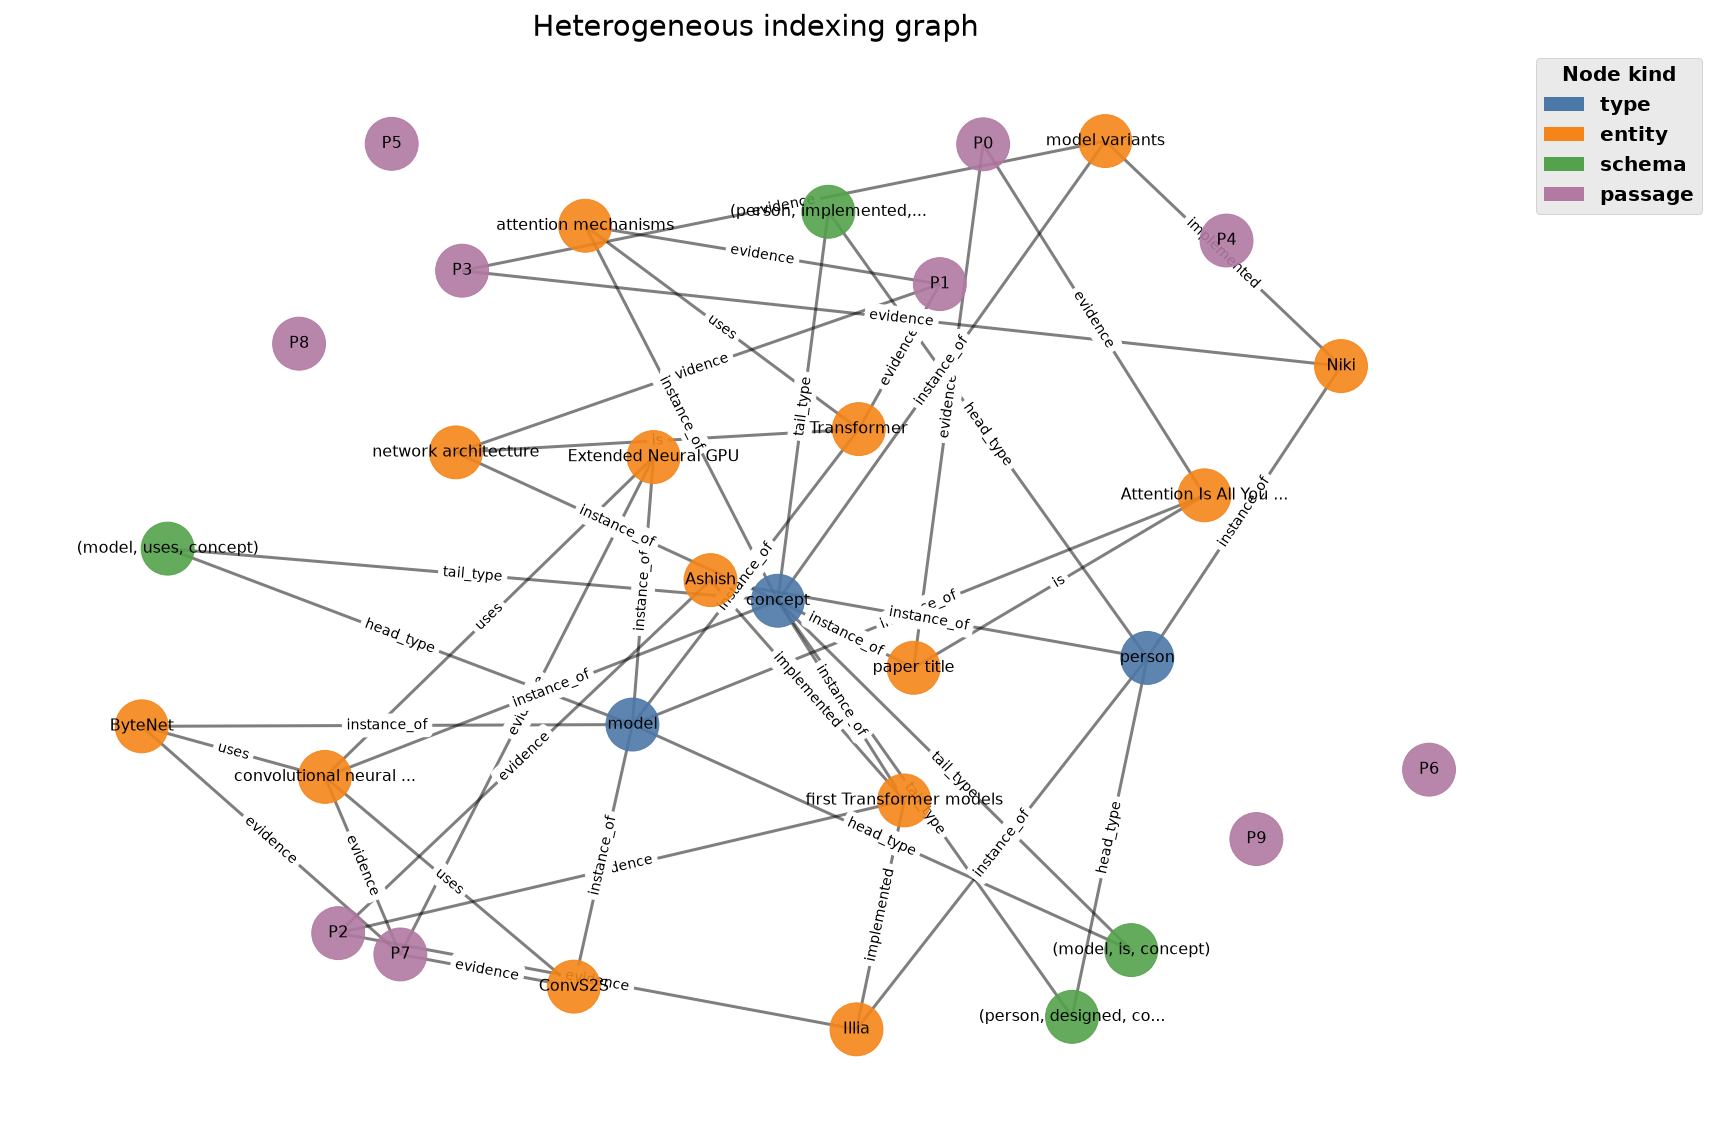

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

KIND_COLORS = {
    'type': '#4C78A8',
    'entity': '#F58518',
    'schema': '#54A24B',
    'passage': '#B279A2',
}

labels = {}
for node_id, data in G.nodes(data=True):
    if data['kind'] == 'passage':
        chunk = index.graph.nodes[node_id].metadata.get('chunk_index', '?')
        labels[node_id] = f'P{chunk}'
    else:
        label = data['label']
        labels[node_id] = label if len(label) <= 24 else label[:21] + '...'

node_colors = [KIND_COLORS.get(G.nodes[n]['kind'], '#999999') for n in G.nodes()]
pos = nx.spring_layout(G, seed=42, k=1.2)

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, width=1.5)
edge_labels = {(u, v): d.get('relation', '') for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

legend_handles = [Patch(facecolor=color, label=kind) for kind, color in KIND_COLORS.items()]
ax.legend(handles=legend_handles, title='Node kind', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_title('Heterogeneous indexing graph')
ax.axis('off')
plt.tight_layout()
plt.show()